In [19]:
import pandas as pd
df=pd.read_csv("/content/Iris.csv")


In [20]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [21]:
df.shape

(150, 6)

In [22]:
df.isnull().sum()

,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [23]:
df = df.iloc[:,1:]


In [ ]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [24]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [25]:
df['Species'].unique()

array([0, 1, 2])

In [26]:
# remove Species[0] to make classification problem and select to columns for simplification
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]

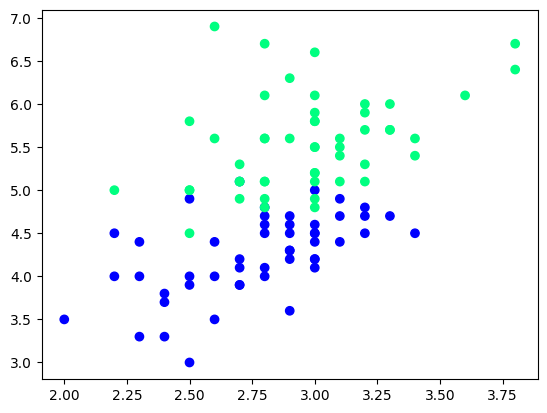

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [28]:
df= df.sample(100)
df.head()


,SepalWidthCm,PetalLengthCm,Species
105,3.0,6.6,2
99,2.8,4.1,1
75,3.0,4.4,1
79,2.6,3.5,1
147,3.0,5.2,2


In [29]:
df_train = df.iloc[:60,:]
df_val = df.iloc[60:80,:]
df_test = df.iloc[80:,:]

In [ ]:
df_train

,SepalWidthCm,PetalLengthCm,Species
76,2.8,4.8,1
58,2.9,4.6,1
149,3.0,5.1,2
140,3.1,5.6,2
111,2.7,5.3,2
139,3.1,5.4,2
110,3.2,5.1,2
60,2.0,3.5,1
114,2.8,5.1,2
116,3.0,5.5,2


In [ ]:
df_val

,SepalWidthCm,PetalLengthCm,Species
147,3.0,5.2,2
101,2.7,5.1,2
52,3.1,4.9,1
99,2.8,4.1,1
92,2.6,4.0,1
79,2.6,3.5,1
50,3.2,4.7,1
67,2.7,4.1,1
70,3.2,4.8,1
127,3.0,4.9,2


In [ ]:
df_test

,SepalWidthCm,PetalLengthCm,Species
135,3.0,6.1,2
103,2.9,5.6,2
62,2.2,4.0,1
80,2.4,3.8,1
56,3.3,4.7,1
53,2.3,4.0,1
94,2.7,4.2,1
82,2.7,3.9,1
112,3.0,5.5,2
138,3.0,4.8,2


In [30]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [31]:
y_test

array([2, 1, 1, 1, 2, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 1, 1, 2, 1, 2])

BAGGING

In [33]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [32]:
# Data for Tree 1
df_bag = df_train.sample(20,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
95,3.0,4.2,1
53,2.3,4.0,1
68,2.2,4.5,1
62,2.2,4.0,1
128,2.8,5.6,2
55,2.8,4.5,1
53,2.3,4.0,1
67,2.7,4.1,1
60,2.0,3.5,1
111,2.7,5.3,2


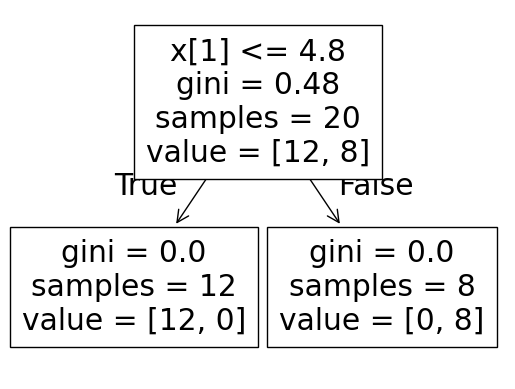

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.9


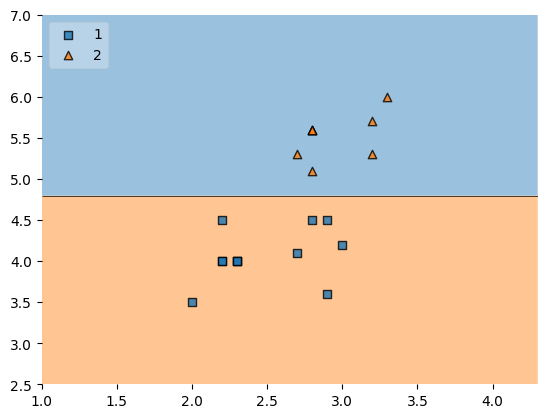

In [35]:
dt_bag1 = DecisionTreeClassifier()
evaluate(dt_bag1,X,y)

In [37]:
# Data for Tree 2
df_bag = df_train.sample(20,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
95,3.0,4.2,1
100,3.3,6.0,2
105,3.0,6.6,2
112,3.0,5.5,2
114,2.8,5.1,2
107,2.9,6.3,2
59,2.7,3.9,1
146,2.5,5.0,2
84,3.0,4.5,1


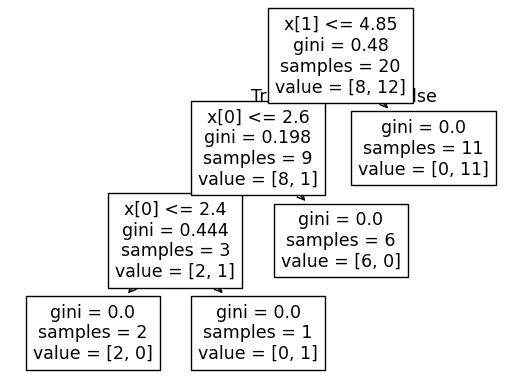

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.8


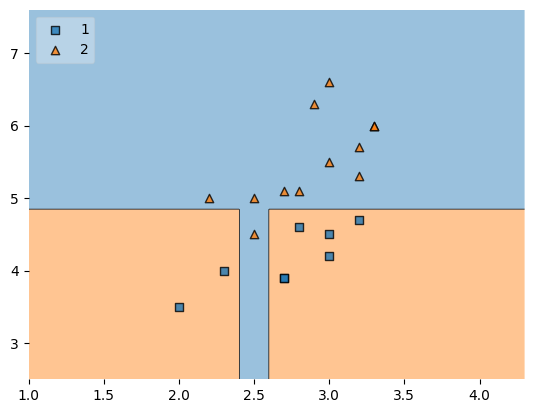

In [38]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [39]:
# Data for Tree 3
df_bag = df_train.sample(20,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
90,2.6,4.4,1
97,2.9,4.3,1
144,3.3,5.7,2
50,3.2,4.7,1
132,2.8,5.6,2
144,3.3,5.7,2
82,2.7,3.9,1
75,3.0,4.4,1
54,2.8,4.6,1
137,3.1,5.5,2


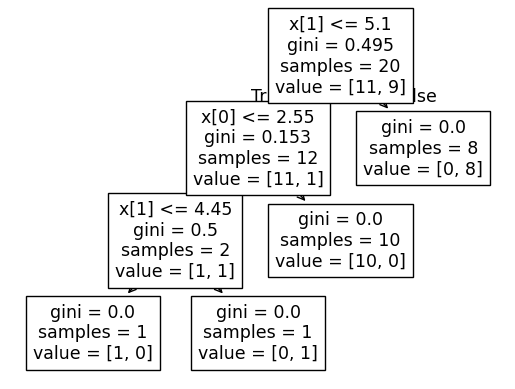

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.85


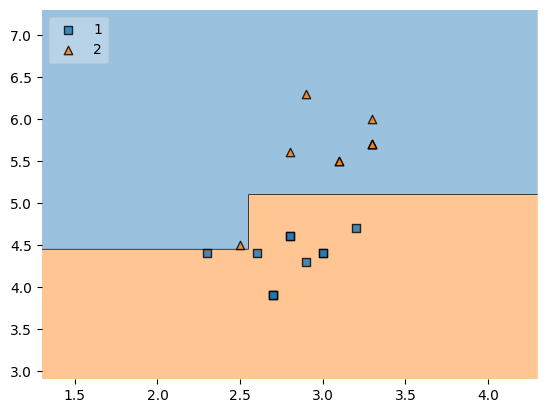

In [40]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)

PREDICT

In [41]:
df_test

,SepalWidthCm,PetalLengthCm,Species
96,2.9,4.2,1
131,3.8,6.4,2
88,3.0,4.1,1
98,2.5,3.0,1
143,3.2,5.9,2
149,3.0,5.1,2
86,3.1,4.7,1
139,3.1,5.4,2
138,3.0,4.8,2
66,3.0,4.5,1


In [45]:
import numpy as np

print("Predictor 1",dt_bag1.predict(np.array([2.8,6.1]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.8,6.1]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.8,6.1]).reshape(1,2)))

Predictor 1 [2]
Predictor 2 [2]
Predictor 3 [2]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [34]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))